# RCPSPTT Benchmark Results - 8.4.2026

Analysis of IBM CPO vs OptalCP on RCPSP with Transfer Times instances (j30, j60, j90, j120).

Data are from https://www2.informatik.uni-osnabrueck.de/kombopt/data/rcpsp/
Instances of RCPSP with transfer times, used in Poppenborg, Knust [2016]:

**Setup:** 120s time limit, 8 workers per instance.

In [1]:
import json
import pandas as pd
from pathlib import Path

DATA_DIR = Path(".")
SOLVERS = ["optal", "cpo"]
SETS = ["j30", "j60", "j90", "j120"]

# Load all results into a single DataFrame
rows = []
for solver in SOLVERS:
    for s in SETS:
        fp = DATA_DIR / f"{solver}_{s}.json"
        with open(fp) as f:
            for r in json.load(f):
                r["set"] = s
                rows.append(r)

df = pd.DataFrame(rows)
df["set"] = pd.Categorical(df["set"], categories=SETS, ordered=True)
print(f"Loaded {len(df)} results ({df['solver'].nunique()} solvers × {df['set'].nunique()} sets)")

Loaded 408 results (2 solvers × 4 sets)


## State counts per solver and set

In [11]:
# Pivot: rows = (set, solver), columns = state
state_table = (df.groupby(["set", "solver", "state"])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=["Optimal", "Feasible", "NoSolution", "Error"], fill_value=0))

# Add total and solved columns
state_table["Total"] = state_table.sum(axis=1)
state_table["Solved"] = state_table["Optimal"] + state_table["Feasible"]
state_table["Solved %"] = (state_table["Solved"] / state_table["Total"] * 100).round(1)

state_table

/tmp/ipykernel_345925/1937251961.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_table = (df.groupby(["set", "solver", "state"])


state        Optimal  Feasible  NoSolution  Error  Total  Solved  Solved %
set  solver                                                               
j30  cpo          16        29           3      0     48      45      93.8
     optal        19         1          28      0     48      20      41.7
j60  cpo          12        30           6      0     48      42      87.5
     optal        10         0          38      0     48      10      20.8
j90  cpo           6        38           4      0     48      44      91.7
     optal         3         0          45      0     48       3       6.2
j120 cpo           0        40          20      0     60      40      66.7
     optal         0         0          60      0     60       0       0.0

## Solved instances by solver and set

/tmp/ipykernel_345925/2807448494.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals_by_set = df.groupby("set")["instance"].nunique()


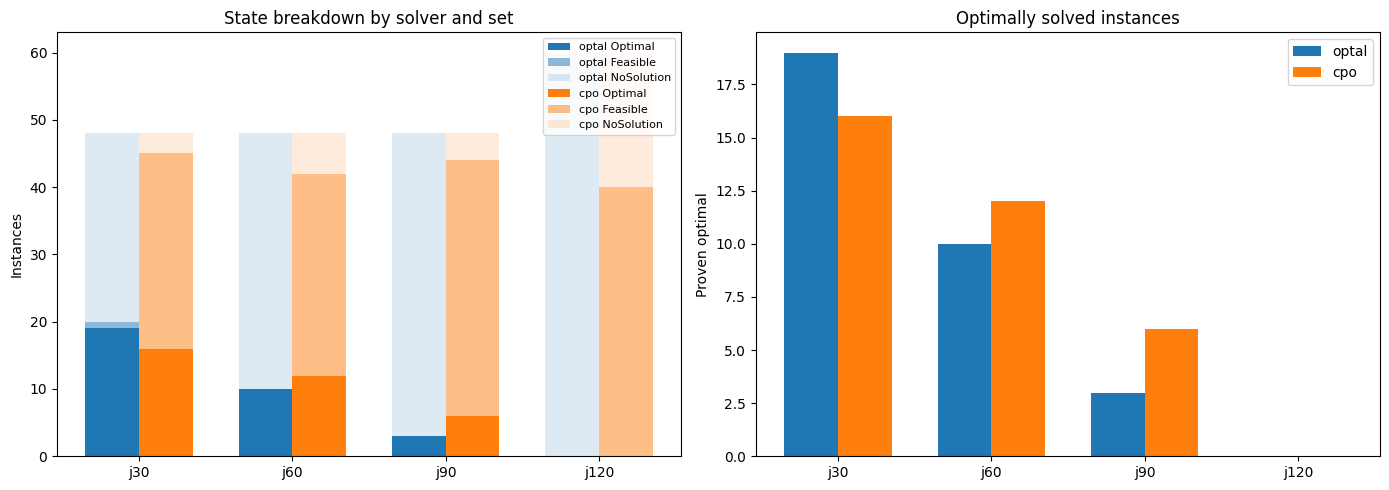

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: stacked bar chart (Optimal / Feasible / NoSolution) ---
ax = axes[0]
totals_by_set = df.groupby("set")["instance"].nunique()
x = np.arange(len(SETS))
width = 0.35

for i, solver in enumerate(SOLVERS):
    sub = df[df["solver"] == solver]
    optimal = [len(sub[(sub["set"] == s) & (sub["state"] == "Optimal")]) for s in SETS]
    feasible = [len(sub[(sub["set"] == s) & (sub["state"] == "Feasible")]) for s in SETS]
    nosol = [len(sub[(sub["set"] == s) & (sub["state"] == "NoSolution")]) for s in SETS]

    offset = (i - 0.5) * width
    ax.bar(x + offset, optimal, width, label=f"{solver} Optimal", color=f"C{i}", alpha=1.0)
    ax.bar(x + offset, feasible, width, bottom=optimal, label=f"{solver} Feasible",
           color=f"C{i}", alpha=0.5)
    ax.bar(x + offset, nosol, width,
           bottom=[o + f for o, f in zip(optimal, feasible)],
           label=f"{solver} NoSolution", color=f"C{i}", alpha=0.15)

ax.set_xticks(x)
ax.set_xticklabels(SETS)
ax.set_ylabel("Instances")
ax.set_title("State breakdown by solver and set")
ax.legend(fontsize=8)

# --- Right: Optimal count comparison ---
ax = axes[1]
for i, solver in enumerate(SOLVERS):
    sub = df[(df["solver"] == solver) & (df["state"] == "Optimal")]
    counts = [len(sub[sub["set"] == s]) for s in SETS]
    ax.bar(x + (i - 0.5) * width, counts, width, label=solver, color=f"C{i}")

ax.set_xticks(x)
ax.set_xticklabels(SETS)
ax.set_ylabel("Proven optimal")
ax.set_title("Optimally solved instances")
ax.legend()

plt.tight_layout()
plt.show()

## Runtime and best solution time statistics

In [4]:
# Only look at instances that found at least a feasible solution
solved = df[df["state"].isin(["Optimal", "Feasible"])].copy()

time_stats = (solved.groupby(["set", "solver"])
              .agg(
                  count=("instance", "size"),
                  avg_duration=("duration", "mean"),
                  max_duration=("duration", "max"),
                  avg_bst=("best_solution_time", "mean"),
                  median_bst=("best_solution_time", "median"),
                  max_bst=("best_solution_time", "max"),
                  avg_build=("build_time", "mean"),
              )
              .round(3))

time_stats

/tmp/ipykernel_345925/2007209508.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_stats = (solved.groupby(["set", "solver"])


count  avg_duration  max_duration  avg_bst  median_bst  max_bst  \
set  solver                                                                    
j30  cpo        45        82.216       120.241    0.029       0.030    0.060   
     optal      20        12.746       120.050   10.328       0.122   71.968   
j60  cpo        42        93.464       120.839    0.093       0.055    0.240   
     optal      10        14.799        51.864   14.755      10.616   51.760   
j90  cpo        44       107.914       122.340    0.301       0.135    0.810   
     optal       3        37.340        88.541   37.272      12.644   88.473   
j120 cpo        40       121.837       127.106    0.779       0.250    3.240   
     optal       0           NaN           NaN      NaN         NaN      NaN   

             avg_build  
set  solver             
j30  cpo         0.045  
     optal       0.010  
j60  cpo         0.218  
     optal       0.052  
j90  cpo         0.536  
     optal       0.086  
j120 cpo         1.181  
     optal         NaN

## Objective comparison on common instances

In [5]:
# Pivot to compare objectives side-by-side
pivot = df.pivot_table(index=["set", "instance"], columns="solver",
                       values=["objective", "state", "duration", "best_solution_time"],
                       aggfunc="first")

# Instances where both solvers found a solution
both_solved = pivot.dropna(subset=[("objective", "optal"), ("objective", "cpo")])

obj_optal = both_solved[("objective", "optal")]
obj_cpo = both_solved[("objective", "cpo")]

optal_wins = (obj_optal < obj_cpo).sum()
cpo_wins = (obj_cpo < obj_optal).sum()
ties = (obj_optal == obj_cpo).sum()

print(f"Instances where BOTH solvers found a solution: {len(both_solved)}")
print(f"  OptalCP better objective: {optal_wins}")
print(f"  CPO better objective:     {cpo_wins}")
print(f"  Same objective:           {ties}")
print()

# Instances solved by only one solver
optal_only = df[(df["solver"] == "optal") & (df["objective"].notna())].set_index("instance")
cpo_only = df[(df["solver"] == "cpo") & (df["objective"].notna())].set_index("instance")

only_optal = set(optal_only.index) - set(cpo_only.index)
only_cpo = set(cpo_only.index) - set(optal_only.index)

print(f"Solved ONLY by OptalCP: {len(only_optal)}")
print(f"Solved ONLY by CPO:     {len(only_cpo)}")

Instances where BOTH solvers found a solution: 33
  OptalCP better objective: 3
  CPO better objective:     1
  Same objective:           29

Solved ONLY by OptalCP: 0
Solved ONLY by CPO:     138


/tmp/ipykernel_345925/2536163909.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index=["set", "instance"], columns="solver",


## Best solution time distribution (solved instances only)

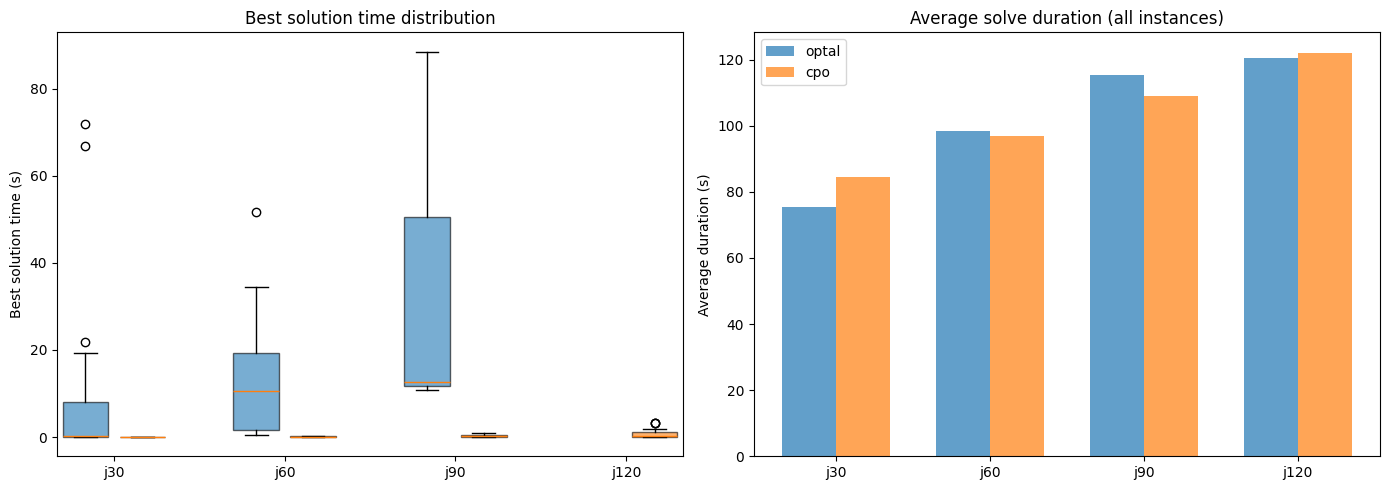

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Best solution time by set (box plot) ---
ax = axes[0]
positions = []
labels = []
data_to_plot = []
colors = []
color_map = {"optal": "C0", "cpo": "C1"}

for j, s in enumerate(SETS):
    for k, solver in enumerate(SOLVERS):
        sub = solved[(solved["set"] == s) & (solved["solver"] == solver)]
        bst = sub["best_solution_time"].dropna()
        if len(bst) > 0:
            data_to_plot.append(bst.values)
            positions.append(j * 3 + k)
            labels.append(f"{s}\n{solver}" if k == 0 else f"\n{solver}")
            colors.append(color_map[solver])

bp = ax.boxplot(data_to_plot, positions=positions, widths=0.8, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xticks([j * 3 + 0.5 for j in range(len(SETS))])
ax.set_xticklabels(SETS)
ax.set_ylabel("Best solution time (s)")
ax.set_title("Best solution time distribution")

# --- Right: Duration (total solve time) by set ---
ax = axes[1]
for i, solver in enumerate(SOLVERS):
    sub = df[df["solver"] == solver]
    avg_dur = [sub[sub["set"] == s]["duration"].mean() for s in SETS]
    ax.bar(x + (i - 0.5) * width, avg_dur, width, label=solver, color=f"C{i}", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(SETS)
ax.set_ylabel("Average duration (s)")
ax.set_title("Average solve duration (all instances)")
ax.legend()

plt.tight_layout()
plt.show()

## Detailed per-set summary

In [7]:
for s in SETS:
    sub = df[df["set"] == s]
    n_instances = sub["instance"].nunique()
    print(f"\n{'='*60}")
    print(f"  {s.upper()} — {n_instances} instances")
    print(f"{'='*60}")

    for solver in SOLVERS:
        ss = sub[sub["solver"] == solver]
        n_opt = len(ss[ss["state"] == "Optimal"])
        n_feas = len(ss[ss["state"] == "Feasible"])
        n_nosol = len(ss[ss["state"] == "NoSolution"])
        n_solved = n_opt + n_feas

        print(f"\n  {solver.upper()}:")
        print(f"    Optimal:    {n_opt}/{len(ss)} ({n_opt/len(ss)*100:.0f}%)")
        print(f"    Feasible:   {n_feas}/{len(ss)} ({n_feas/len(ss)*100:.0f}%)")
        print(f"    NoSolution: {n_nosol}/{len(ss)} ({n_nosol/len(ss)*100:.0f}%)")

        ss_solved = ss[ss["state"].isin(["Optimal", "Feasible"])]
        if len(ss_solved) > 0:
            bst = ss_solved["best_solution_time"].dropna()
            print(f"    Avg best solution time: {bst.mean():.3f}s" if len(bst) > 0 else "")
            print(f"    Avg total duration:     {ss_solved['duration'].mean():.3f}s")
            print(f"    Avg build time:         {ss_solved['build_time'].mean():.3f}s")


  J30 — 48 instances

  OPTAL:
    Optimal:    19/48 (40%)
    Feasible:   1/48 (2%)
    NoSolution: 28/48 (58%)
    Avg best solution time: 10.328s
    Avg total duration:     12.746s
    Avg build time:         0.010s

  CPO:
    Optimal:    16/48 (33%)
    Feasible:   29/48 (60%)
    NoSolution: 3/48 (6%)
    Avg best solution time: 0.029s
    Avg total duration:     82.216s
    Avg build time:         0.045s

  J60 — 48 instances

  OPTAL:
    Optimal:    10/48 (21%)
    Feasible:   0/48 (0%)
    NoSolution: 38/48 (79%)
    Avg best solution time: 14.755s
    Avg total duration:     14.799s
    Avg build time:         0.052s

  CPO:
    Optimal:    12/48 (25%)
    Feasible:   30/48 (62%)
    NoSolution: 6/48 (12%)
    Avg best solution time: 0.093s
    Avg total duration:     93.464s
    Avg build time:         0.218s

  J90 — 48 instances

  OPTAL:
    Optimal:    3/48 (6%)
    Feasible:   0/48 (0%)
    NoSolution: 45/48 (94%)
    Avg best solution time: 37.272s
    Avg total dur

## Objective scatter plot (OptalCP vs CPO)

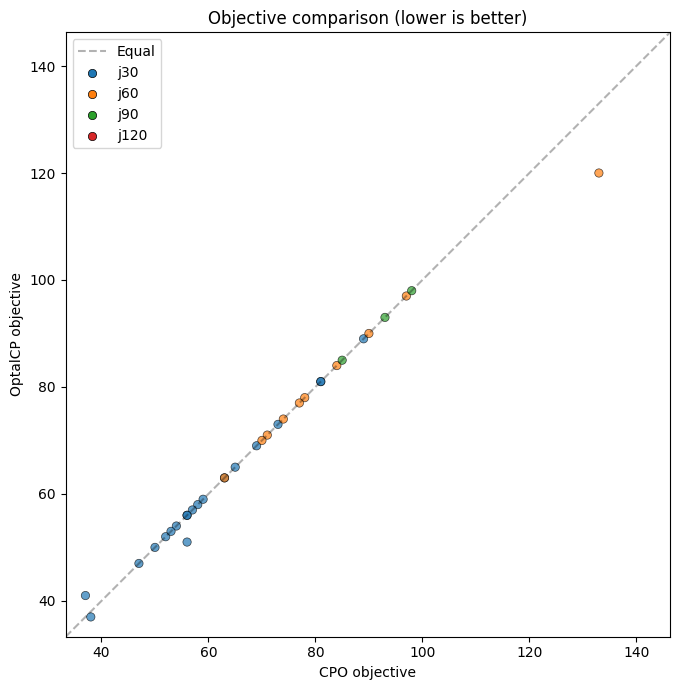

In [8]:
if len(both_solved) > 0:
    fig, ax = plt.subplots(figsize=(7, 7))

    obj_o = both_solved[("objective", "optal")].values
    obj_c = both_solved[("objective", "cpo")].values

    # Color by set
    set_colors = {"j30": "C0", "j60": "C1", "j90": "C2", "j120": "C3"}
    colors = [set_colors[s] for s, _ in both_solved.index]

    ax.scatter(obj_c, obj_o, c=colors, alpha=0.7, edgecolors="k", linewidths=0.5)

    lo = min(min(obj_o), min(obj_c)) * 0.9
    hi = max(max(obj_o), max(obj_c)) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.3, label="Equal")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("CPO objective")
    ax.set_ylabel("OptalCP objective")
    ax.set_title("Objective comparison (lower is better)")
    ax.set_aspect("equal")

    # Legend for sets
    for s, c in set_colors.items():
        ax.scatter([], [], c=c, label=s, edgecolors="k", linewidths=0.5)
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No instances solved by both solvers — cannot create scatter plot.")

## Unsolved instances

In [9]:
# Instances where NEITHER solver found any solution
no_sol_both = (df[df["state"] == "NoSolution"]
               .groupby(["set", "instance"])
               .size()
               .reset_index(name="n_solvers_failed"))
unsolved_by_both = no_sol_both[no_sol_both["n_solvers_failed"] == 2]

print(f"Instances unsolved by BOTH solvers: {len(unsolved_by_both)}")
print(f"  Per set: {unsolved_by_both.groupby('set').size().to_dict()}")
print()

# Instances where at least one solver found no solution
any_nosol = df[df["state"] == "NoSolution"].groupby("set").size()
print("NoSolution counts (total across solvers):")
print(any_nosol.to_string())

Instances unsolved by BOTH solvers: 33
  Per set: {'j30': 3, 'j60': 6, 'j90': 4, 'j120': 20}

NoSolution counts (total across solvers):
set
j30     31
j60     44
j90     49
j120    80


/tmp/ipykernel_345925/3489462758.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["set", "instance"])
/tmp/ipykernel_345925/3489462758.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"  Per set: {unsolved_by_both.groupby('set').size().to_dict()}")
/tmp/ipykernel_345925/3489462758.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  any_nosol = df[df["state"] == "NoSolution"].groupby("set").size()


## Summary table

In [10]:
summary_rows = []
for solver in SOLVERS:
    for s in SETS:
        sub = df[(df["solver"] == solver) & (df["set"] == s)]
        n = len(sub)
        n_opt = len(sub[sub["state"] == "Optimal"])
        n_feas = len(sub[sub["state"] == "Feasible"])
        n_nosol = len(sub[sub["state"] == "NoSolution"])
        ss = sub[sub["state"].isin(["Optimal", "Feasible"])]
        bst = ss["best_solution_time"].dropna()

        summary_rows.append({
            "Solver": solver.upper(),
            "Set": s,
            "Total": n,
            "Optimal": n_opt,
            "Feasible": n_feas,
            "NoSolution": n_nosol,
            "Solved %": f"{(n_opt + n_feas) / n * 100:.0f}%",
            "Avg BST (s)": f"{bst.mean():.2f}" if len(bst) > 0 else "—",
            "Avg Duration (s)": f"{ss['duration'].mean():.1f}" if len(ss) > 0 else "—",
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.hide(axis="index")

Solver,Set,Total,Optimal,Feasible,NoSolution,Solved %,Avg BST (s),Avg Duration (s)
OPTAL,j30,48,19,1,28,42%,10.33,12.7
OPTAL,j60,48,10,0,38,21%,14.76,14.8
OPTAL,j90,48,3,0,45,6%,37.27,37.3
OPTAL,j120,60,0,0,60,0%,—,—
CPO,j30,48,16,29,3,94%,0.03,82.2
CPO,j60,48,12,30,6,88%,0.09,93.5
CPO,j90,48,6,38,4,92%,0.30,107.9
CPO,j120,60,0,40,20,67%,0.78,121.8
